# Analisis de sentimiento de JPMorgan (JPM) -- FinBERT + Finnhub

Notebook independiente. No modifica ni depende de los notebooks de prediccion (General / Mejorado). Se corre por separado, idealmente una vez por dia, y va acumulando un historial de sentimiento en un CSV propio.

**Que hace:**
1. Pide a Finnhub las noticias de JPM del dia.
2. Le pasa cada titular a **FinBERT** (modelo de lenguaje ya entrenado para leer texto financiero y clasificarlo como positivo / negativo / neutral -- no lo entrenamos nosotros, lo usamos ya hecho, disponible gratis en Hugging Face).
3. Promedia esos resultados en un solo numero de sentimiento para el dia.
4. Guarda ese numero en un CSV historico (una fila por dia).

**Antes de correr, guarda tu API key de Finnhub en los Secrets de Colab** (no la escribas en ninguna celda):
1. En el panel izquierdo de Colab, click en el icono de llave (Secrets).
2. "Add new secret" -> nombre `FINNHUB_API_KEY` -> pega ahi tu key completa (el campo "Clave API" del dashboard de Finnhub, son 40 caracteres).
3. Activa el toggle "Notebook access" para este notebook.

Este historial, con suficientes dias acumulados, es lo que mas adelante permitiria agregar el sentimiento como variable de entrada real al Transformer (hoy no se puede: no hay historial de 2 anios de noticias ya procesado).

In [10]:
# >>> QUE HACE ESTA CELDA: instala las librerias necesarias y monta Google Drive
# (FinBERT vive dentro de la libreria `transformers`, la misma familia que Vaswani et al. hizo popular)
!pip install -q transformers torch requests pandas

from google.colab import drive
drive.mount('/content/drive')

import os
CARPETA_PROYECTO = '/content/drive/MyDrive/ade_ifs'
os.makedirs(CARPETA_PROYECTO, exist_ok=True)
print('Google Drive montado. El historial de sentimiento se guarda en:', CARPETA_PROYECTO)

Mounted at /content/drive
Google Drive montado. El historial de sentimiento se guarda en: /content/drive/MyDrive/ade_ifs


In [3]:
# >>> QUE HACE ESTA CELDA: lee la API key desde los Secrets de Colab (nunca queda escrita aqui) y carga FinBERT
from google.colab import userdata
import requests, datetime, pandas as pd
from transformers import pipeline

FINNHUB_API_KEY = userdata.get('FINNHUB_API_KEY')
TICKER = 'JPM'

assert FINNHUB_API_KEY, 'No se encontro el secret FINNHUB_API_KEY -- revisa el icono de llave en el panel izquierdo.'

print('Cargando FinBERT (puede tardar 1-2 minutos la primera vez que se corre)...')
sentiment_pipeline = pipeline('sentiment-analysis', model='ProsusAI/finbert')
print('FinBERT listo.')

Cargando FinBERT (puede tardar 1-2 minutos la primera vez que se corre)...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT listo.


In [7]:
# >>> QUE HACE ESTA CELDA: pide a Finnhub las noticias de JPM de hoy (con 1 dia de margen por husos horarios)
hoy = datetime.date.today()
desde = hoy - datetime.timedelta(days=1)

url = 'https://finnhub.io/api/v1/company-news'
params = {
    'symbol': TICKER,
    'from': desde.isoformat(),
    'to': hoy.isoformat(),
    'token': FINNHUB_API_KEY,
}
resp = requests.get(url, params=params)
resp.raise_for_status()
noticias = resp.json()

titulares = [n['headline'] for n in noticias if n.get('headline')]
titulares = list(dict.fromkeys(titulares))  # quita titulares duplicados, Finnhub a veces repite

print(f'Se encontraron {len(titulares)} titulares de {TICKER} entre {desde} y {hoy}.')
for t in titulares[:10]:
    print(' -', t[:100])

Se encontraron 22 titulares de JPM entre 2026-08-12 y 2026-08-13.
 - You’ve retired — so grow up already and stop buying these 5 things to save yourself thousands of dol
 - JPMorgan gets bullish on Salesforce, says concerns are "overblown"
 - Best Income Stocks to Buy for August 13th
 - Rand Paul Inspects Fort Knox Gold, Says Dollar’s 97% Collapse Since 1913 Is Behind America’s 'Afford
 - SLS Stock Logs Best Day In Over A Week: JPMorgan Buys In And Stifel Boosts Bet Ahead Of Key AML Data
 - The Goldman Sachs Group (GS)’s $2.3 Billion ETF Bet: How Does It Compare With JPMorgan?
 - Wednesday's session: top gainers and losers in the dow jones index
 - Why Delta and United’s Loyalty Programs Could Be Worth $30 Billion
 - JPMorgan Stock Rises 0.7% as Bank Calls for S&P 8,000
 - Which dow jones stocks are moving on Wednesday?


In [8]:
# >>> QUE HACE ESTA CELDA: le pasa cada titular a FinBERT y promedia el resultado del dia
# FinBERT devuelve, por titular: label (positive/negative/neutral) + score de confianza (0 a 1).
# Lo convertimos a un numero unico: positive=+1, neutral=0, negative=-1, multiplicado por la confianza.
sentimiento_dia = None

if not titulares:
    print('No hay titulares para analizar hoy -- no se puede calcular sentimiento con este metodo ese dia.')
else:
    resultados = sentiment_pipeline(titulares, truncation=True)
    signo = {'positive': 1, 'neutral': 0, 'negative': -1}
    puntajes = [signo[r['label']] * r['score'] for r in resultados]
    sentimiento_dia = sum(puntajes) / len(puntajes)

    print(f'Sentimiento promedio de hoy ({len(titulares)} titulares): {sentimiento_dia:.3f}')
    print('(escala: -1 = muy negativo, 0 = neutral, +1 = muy positivo)\n')
    for h, r, p in zip(titulares, resultados, puntajes):
        print(f"  [{r['label']:8s} conf={r['score']:.2f} -> {p:+.2f}]  {h[:90]}")

Sentimiento promedio de hoy (22 titulares): 0.059
(escala: -1 = muy negativo, 0 = neutral, +1 = muy positivo)

  [neutral  conf=0.90 -> +0.00]  You’ve retired — so grow up already and stop buying these 5 things to save yourself thousa
  [negative conf=0.88 -> -0.88]  JPMorgan gets bullish on Salesforce, says concerns are "overblown"
  [neutral  conf=0.93 -> +0.00]  Best Income Stocks to Buy for August 13th
  [negative conf=0.56 -> -0.56]  Rand Paul Inspects Fort Knox Gold, Says Dollar’s 97% Collapse Since 1913 Is Behind America
  [positive conf=0.88 -> +0.88]  SLS Stock Logs Best Day In Over A Week: JPMorgan Buys In And Stifel Boosts Bet Ahead Of Ke
  [neutral  conf=0.88 -> +0.00]  The Goldman Sachs Group (GS)’s $2.3 Billion ETF Bet: How Does It Compare With JPMorgan?
  [negative conf=0.74 -> -0.74]  Wednesday's session: top gainers and losers in the dow jones index
  [neutral  conf=0.94 -> +0.00]  Why Delta and United’s Loyalty Programs Could Be Worth $30 Billion
  [positive conf=0.38

In [11]:
# >>> QUE HACE ESTA CELDA: guarda el resultado de hoy en el historial CSV (una fila por dia, se va acumulando)
CSV_PATH = os.path.join(CARPETA_PROYECTO, 'sentiment_log_JPM.csv')

fila = pd.DataFrame([{
    'fecha': hoy.isoformat(),
    'n_titulares': len(titulares),
    'sentimiento_promedio': round(sentimiento_dia, 4) if sentimiento_dia is not None else None,
}])

if os.path.exists(CSV_PATH):
    historial = pd.read_csv(CSV_PATH)
    historial = pd.concat([historial[historial['fecha'] != hoy.isoformat()], fila], ignore_index=True)
else:
    historial = fila

historial = historial.sort_values('fecha').reset_index(drop=True)
historial.to_csv(CSV_PATH, index=False)

print(f'Guardado en {CSV_PATH}')
print(f'Historial acumulado: {len(historial)} dia(s).')
historial.tail(10)

Guardado en /content/drive/MyDrive/ade_ifs/sentiment_log_JPM.csv
Historial acumulado: 2 dia(s).


,fecha,n_titulares,sentimiento_promedio
0,2026-08-11,29,0.1246
1,2026-08-13,22,0.0592


## Fusion con la prediccion del notebook Mejorado

Esta parte combina el sentimiento de hoy (ya calculado arriba con FinBERT) con la prediccion del notebook `Resultados_JPMorgan_Transformer_Mejorado.ipynb`, usando la misma formula del script `sentiment_fusion.py`.

**Paso previo:** corre primero el notebook Mejorado, ve a su celda de "PREDICCION A CIEGAS" y copia sus 3 numeros aqui abajo:
- `Prediccion ensemble` -> `prediccion_mejorado`
- El ancho del intervalo ~68% (la mitad de la diferencia entre el limite alto y el bajo) -> `std_mejorado`
- `Ultimo cierre conocido` -> `ultimo_cierre`

In [15]:
# >>> QUE HACE ESTA CELDA: combina el sentimiento de FinBERT de hoy con la prediccion de Mejorado
# Reemplaza estos 3 valores con los que imprimio el notebook Mejorado en 'PREDICCION A CIEGAS'
prediccion_mejorado = 366.21    # ej. 360.13
std_mejorado = 4.19           # ej. 3.845  (la mitad del ancho del intervalo ~68%)
ultimo_cierre = 365.18          # ej. 359.79

assert prediccion_mejorado is not None and std_mejorado is not None and ultimo_cierre is not None, \
    'Completa los 3 valores de arriba con los que imprimio el notebook Mejorado antes de correr esta celda.'
assert sentimiento_dia is not None, 'No hay sentimiento calculado hoy (revisa la celda de arriba, no hubo titulares).'

z_modelo = (prediccion_mejorado - ultimo_cierre) / std_mejorado

def codigo_modelo(z):
    if z <= -0.8: return -2
    if z <= -0.3: return -1
    if z < 0.3: return 0
    if z < 0.8: return 1
    return 2

cod_modelo = codigo_modelo(z_modelo)
score_final = 0.5 * cod_modelo + 0.5 * sentimiento_dia

if score_final >= 1:
    etiqueta = 'ALCISTA -- señal fuerte de compra'
elif score_final <= -1:
    etiqueta = 'BAJISTA -- señal fuerte de venta'
else:
    etiqueta = 'MANTENER -- ni las noticias ni el modelo dan una señal fuerte para comprar o vender.'

print('=' * 60)
print(f'z_modelo (cambio predicho / std): {z_modelo:.3f} -> codigo {cod_modelo}')
print(f'Sentimiento FinBERT de hoy: {sentimiento_dia:.3f}')
print(f'Score final (0.5*modelo + 0.5*sentimiento): {score_final:.3f}')
print(f'CONCLUSION: {etiqueta}')
print('=' * 60)

z_modelo (cambio predicho / std): 0.246 -> codigo 0
Sentimiento FinBERT de hoy: 0.059
Score final (0.5*modelo + 0.5*sentimiento): 0.030
CONCLUSION: MANTENER -- ni las noticias ni el modelo dan una señal fuerte para comprar o vender.


In [16]:
# >>> QUE HACE ESTA CELDA: guarda la fusion de hoy en su propio historial CSV
FUSION_CSV = os.path.join(CARPETA_PROYECTO, 'fusion_sentimiento_mejorado_log.csv')

fila_fusion = pd.DataFrame([{
    'fecha': hoy.isoformat(),
    'prediccion_mejorado': prediccion_mejorado,
    'std_mejorado': std_mejorado,
    'ultimo_cierre': ultimo_cierre,
    'z_modelo': round(z_modelo, 4),
    'codigo_modelo': cod_modelo,
    'sentimiento_finbert': round(sentimiento_dia, 4),
    'score_final': round(score_final, 4),
    'conclusion': etiqueta,
}])

if os.path.exists(FUSION_CSV):
    hist_fusion = pd.read_csv(FUSION_CSV)
    hist_fusion = pd.concat([hist_fusion[hist_fusion['fecha'] != hoy.isoformat()], fila_fusion], ignore_index=True)
else:
    hist_fusion = fila_fusion

hist_fusion.to_csv(FUSION_CSV, index=False)
print(f'Guardado en {FUSION_CSV}')
hist_fusion.tail(5)

Guardado en /content/drive/MyDrive/ade_ifs/fusion_sentimiento_mejorado_log.csv


,fecha,prediccion_mejorado,std_mejorado,ultimo_cierre,z_modelo,codigo_modelo,sentimiento_finbert,score_final,conclusion
0,2026-08-13,366.21,4.19,365.18,0.2458,0,0.0592,0.0296,MANTENER -- ni las noticias ni el modelo dan u...


## Grafica del historial de fusion

Muestra, dia a dia, el score final combinado (modelo + sentimiento) y sus dos componentes por separado. Al principio va a verse con pocos puntos -- se llena solo, cada vez que corras este notebook en un dia nuevo.

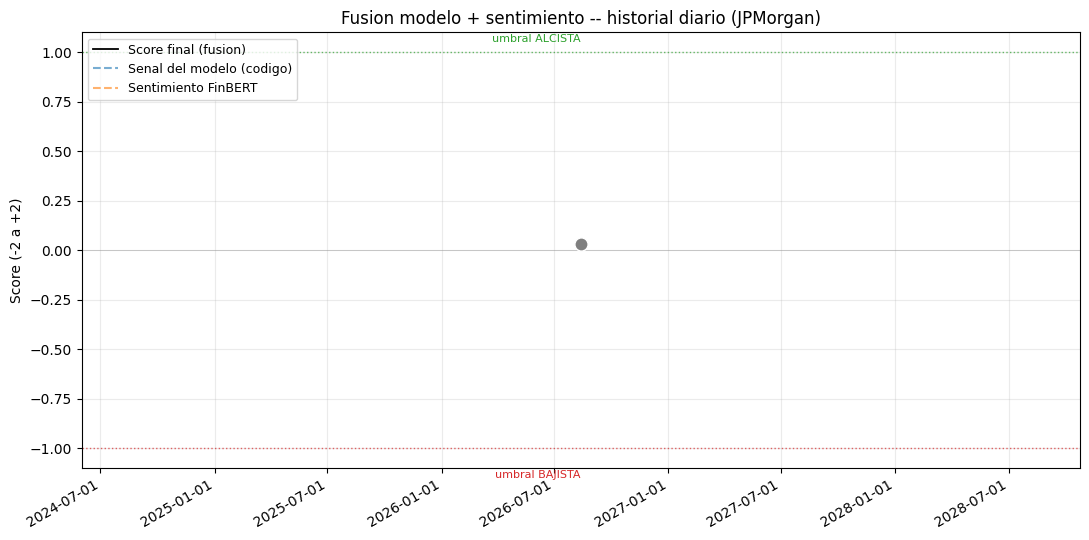

Dias en el historial: 1


In [17]:
# >>> QUE HACE ESTA CELDA: grafica el historial acumulado de fusion (score_final, sentimiento, senal del modelo)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if not os.path.exists(FUSION_CSV):
    print('Todavia no hay historial de fusion guardado -- corre primero las celdas de arriba al menos una vez.')
else:
    hist = pd.read_csv(FUSION_CSV, parse_dates=['fecha']).sort_values('fecha')

    fig, ax = plt.subplots(figsize=(11, 5.5))

    colores = hist['conclusion'].map({
        'ALCISTA': 'tab:green',
        'BAJISTA': 'tab:red',
        'NEUTRO / NO CONCLUYENTE': 'tab:gray',
    }).fillna('tab:gray')

    ax.plot(hist['fecha'], hist['score_final'], '-', color='black', linewidth=1.3, zorder=2, label='Score final (fusion)')
    ax.scatter(hist['fecha'], hist['score_final'], c=colores, s=90, zorder=3, edgecolor='white')
    ax.plot(hist['fecha'], hist['codigo_modelo'], '--', color='tab:blue', alpha=0.6, label='Senal del modelo (codigo)')
    ax.plot(hist['fecha'], hist['sentimiento_finbert'], '--', color='tab:orange', alpha=0.6, label='Sentimiento FinBERT')

    ax.axhline(1, color='tab:green', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(-1, color='tab:red', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.6, alpha=0.4)
    ax.text(hist['fecha'].iloc[-1], 1.05, 'umbral ALCISTA', fontsize=8, color='tab:green', ha='right')
    ax.text(hist['fecha'].iloc[-1], -1.15, 'umbral BAJISTA', fontsize=8, color='tab:red', ha='right')

    ax.set_title('Fusion modelo + sentimiento -- historial diario (JPMorgan)')
    ax.set_ylabel('Score (-2 a +2)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"Dias en el historial: {len(hist)}")
    hist[['fecha', 'codigo_modelo', 'sentimiento_finbert', 'score_final', 'conclusion']].tail(10)

## Como seguir desde aqui

- **Corre este notebook una vez al dia** (idealmente antes de correr el de prediccion), asi el historial de `sentiment_log_JPM.csv` va creciendo dia a dia, igual que la tabla de predicciones acumuladas.
- **Con pocos dias acumulados** (como al principio), usa este numero como referencia informal, igual a como veniamos leyendo el sentimiento manualmente en el chat -- no metas todavia el sentimiento como variable de entrada del Transformer.
- **Cuando tengas varias semanas/meses de historial**, ahi si tendria sentido evaluar agregar `sentimiento_promedio` como columna adicional (junto a Close, SMA_5, Volume_log) y reentrenar el modelo Mejorado con esa variable nueva -- siguiendo la logica de Yang et al. 2025 (TFT-ASRO) sobre variables adicionales de sensor/sentimiento.